# Tutorial 

From [HERE](https://toast-cmb.readthedocs.io/en/toast3/tutorial_intro.html)

In [4]:
# Built-in modules
import sys
import os
from datetime import datetime

# External modules
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u

# For interactive visualization of observations
import ipywidgets as widgets
from IPython.display import display, clear_output
import plotly.graph_objects as go

# TOAST
import toast
import toast.widgets as tw

# Capture C++ output in the jupyter cells
%load_ext wurlitzer

# Display inline plots
%matplotlib inline

The wurlitzer extension is already loaded. To reload it, use:
  %reload_ext wurlitzer


# Data Model

The basic data model in a toast workflow consists of a set of `Observation` instances, each of which is associated with a `Focalplane` on a `Telescope`.

In [5]:
# Start by making a fake focalplane
from toast.instrument_sim import (
    fake_hexagon_focalplane,
    plot_focalplane,
)

focalplane_pixels = 7 # (hexagonal, pixel zero at center)
field_of_view = 10.0 * u.degree
sample_rate = 10.0 * u.Hz

focalplane = fake_hexagon_focalplane(
    n_pix=focalplane_pixels,
    width=field_of_view,
    sample_rate=sample_rate,
    epsilon=0.0,
)

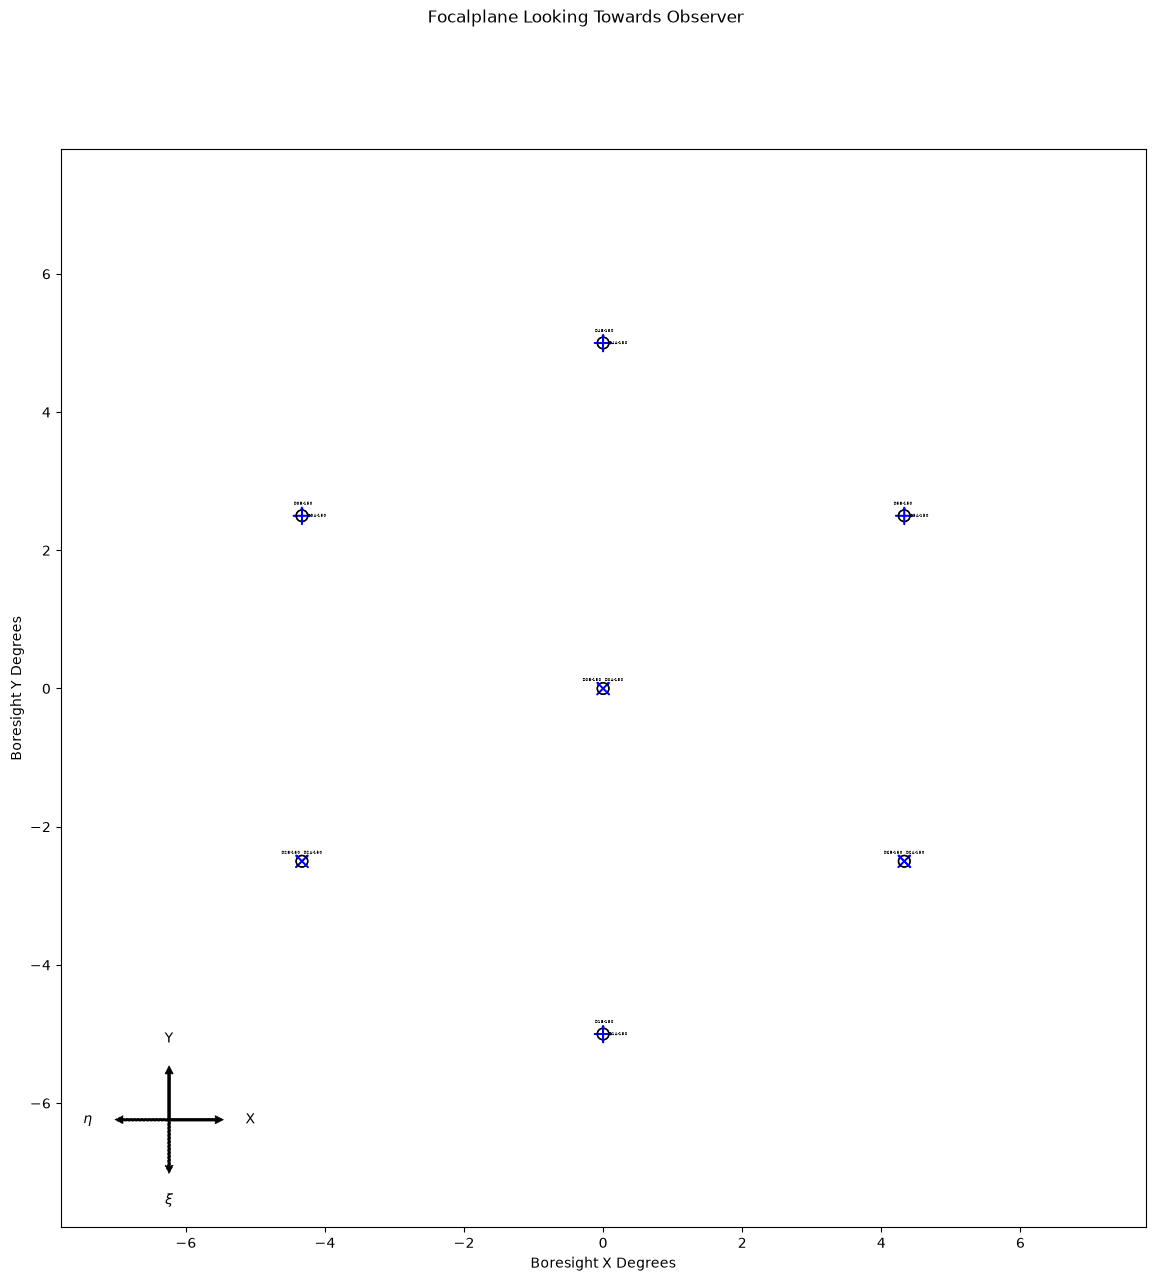

In [6]:
# Make a plot of this focalplane layout.
detpolcol = {
    x: "red" if x.endswith("A") else "blue" for x in focalplane.detectors
}

_ = plot_focalplane(
    focalplane=focalplane,
    width=1.3 * field_of_view,
    height=1.3 * field_of_view,
    show_labels=True,
    pol_color=detpolcol
)

In [7]:
# Now make a fake telescope

telescope = toast.Telescope(name="fake", focalplane=focalplane, site=toast.SpaceSite(name="L2"))

In [8]:
# Make an empty observation

samples = 10

ob = toast.Observation(
    toast.Comm(),
    telescope, 
    name="2020-07-31_A", 
    n_samples=samples
)

print(ob)

<Observation
  name = '2020-07-31_A'
  uid = '733887827'  group has 1 processes
  telescope = <Telescope 'fake': uid = 1872579604, site = <SpaceSite 'L2' : uid = 1436707454>, focalplane = <Focalplane: 14 detectors, sample_rate = 10.0 Hz, FOV = 11.366666666666669 deg, detectors = [D0A-150 .. D6B-150]>>
  session = <Session '2020-07-31_A': uid = 733887827, start = None, end = None>
  10 total samples (10 local)
  shared:  <SharedDataManager>
  detdata:  <DetDataManager 14 local detectors, 10 samples>
  intervals:  <IntervalsManager 1 lists>
>


# Detector Data

Detector data has some unique properties that we often want to leverage in our analyses. Each process has some detectors and some time slice of the observation. In the case of a single process like this example, all the data is local. Before using data we need to create it within the empty Observation. Here we create a “signal” object for the detectors. The detector data is accessed under the `detdata` attribute of the observation:

Here we create and initialize to zero some detector data named “signal”. This has one value per sample per detector and each value is a 64bit float.

In [9]:
if 'signal' not in ob.detdata:
    ob.detdata.create("signal", dtype=np.float64)

You can create other types of detector data, and there is some shortcut notation that can be used to create detector data objects from existing arrays. For example:

By default you will get detector data with one element per sample and float64 dtype. However, you can specify the shape of each detector sample:

In [10]:
# Example of data with different shape

ob.detdata.create("pointing", sample_shape=(4,), dtype=np.float32)
print(ob.detdata["pointing"])

<DetectorData 14 detectors each with shape (10, 4), type float32, units :
  D0A-150 = [ [0. 0. 0. 0.] [0. 0. 0. 0.] ... [0. 0. 0. 0.] [0. 0. 0. 0.] ]
  D0B-150 = [ [0. 0. 0. 0.] [0. 0. 0. 0.] ... [0. 0. 0. 0.] [0. 0. 0. 0.] ]
  D1A-150 = [ [0. 0. 0. 0.] [0. 0. 0. 0.] ... [0. 0. 0. 0.] [0. 0. 0. 0.] ]
  D1B-150 = [ [0. 0. 0. 0.] [0. 0. 0. 0.] ... [0. 0. 0. 0.] [0. 0. 0. 0.] ]
  D2A-150 = [ [0. 0. 0. 0.] [0. 0. 0. 0.] ... [0. 0. 0. 0.] [0. 0. 0. 0.] ]
  D2B-150 = [ [0. 0. 0. 0.] [0. 0. 0. 0.] ... [0. 0. 0. 0.] [0. 0. 0. 0.] ]
  D3A-150 = [ [0. 0. 0. 0.] [0. 0. 0. 0.] ... [0. 0. 0. 0.] [0. 0. 0. 0.] ]
  D3B-150 = [ [0. 0. 0. 0.] [0. 0. 0. 0.] ... [0. 0. 0. 0.] [0. 0. 0. 0.] ]
  D4A-150 = [ [0. 0. 0. 0.] [0. 0. 0. 0.] ... [0. 0. 0. 0.] [0. 0. 0. 0.] ]
  D4B-150 = [ [0. 0. 0. 0.] [0. 0. 0. 0.] ... [0. 0. 0. 0.] [0. 0. 0. 0.] ]
  D5A-150 = [ [0. 0. 0. 0.] [0. 0. 0. 0.] ... [0. 0. 0. 0.] [0. 0. 0. 0.] ]
  D5B-150 = [ [0. 0. 0. 0.] [0. 0. 0. 0.] ... [0. 0. 0. 0.] [0. 0. 0. 0.] ]
  D6A-150 = [ 

## Details of Detector Data

In the commands above we created named data objects and each one seems to contain an array for each detector. However, this container actually allocates memory in a single block, and you can slice the object both in the detector and sample direction. For example:

In [11]:
# Access one detector by name
ob.detdata["signal"]["D0A-150"] = np.arange(samples, dtype=np.float64)

# Access one detector by index
ob.detdata["signal"][1] = 10.0 * np.arange(samples, dtype=np.float64)

# Slice by both detector and sample
ob.detdata["signal"][["D2A-150", "D2B-150"], 0:2] = 5.0

print(ob.detdata["signal"])

<DetectorData 14 detectors each with shape (10,), type float64, units :
  D0A-150 = [ 0.0 1.0 ... 8.0 9.0 ]
  D0B-150 = [ 0.0 10.0 ... 80.0 90.0 ]
  D1A-150 = [ 0.0 0.0 ... 0.0 0.0 ]
  D1B-150 = [ 0.0 0.0 ... 0.0 0.0 ]
  D2A-150 = [ 5.0 5.0 ... 0.0 0.0 ]
  D2B-150 = [ 5.0 5.0 ... 0.0 0.0 ]
  D3A-150 = [ 0.0 0.0 ... 0.0 0.0 ]
  D3B-150 = [ 0.0 0.0 ... 0.0 0.0 ]
  D4A-150 = [ 0.0 0.0 ... 0.0 0.0 ]
  D4B-150 = [ 0.0 0.0 ... 0.0 0.0 ]
  D5A-150 = [ 0.0 0.0 ... 0.0 0.0 ]
  D5B-150 = [ 0.0 0.0 ... 0.0 0.0 ]
  D6A-150 = [ 0.0 0.0 ... 0.0 0.0 ]
  D6B-150 = [ 0.0 0.0 ... 0.0 0.0 ]
>


In [12]:
# Access the whole thing as a 2D array
print(ob.detdata["signal"][:])

[array([0., 1., 2., 3., 4., 5., 6., 7., 8., 9.]), array([ 0., 10., 20., 30., 40., 50., 60., 70., 80., 90.]), array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), array([5., 5., 0., 0., 0., 0., 0., 0., 0., 0.]), array([5., 5., 0., 0., 0., 0., 0., 0., 0., 0.]), array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])]


# Shared Data

Many types of data are common to multiple detectors. Some examples would be telescope pointing, timestamps, other sensor data, etc. When running in parallel we want to have just one copy of this data per node in order to save memory. The shared data is accessed under the “shared” attribute of the observation. For this serial notebook, you will not need to worry about the details of communicators, but when running in parallel it becomes important.

For this serial notebook, the `shared` attribute will look very much like a dictionary of numpy arrays. See the “parallel” intro notebook for more examples of using shared data when each observation is distributed across a grid of processes.

In [13]:
# Shared data that is common to multiple detectors is shared across each "column"
# of the process grid within a group.

# Some fake timestamps:
ob.shared.create_column("times", (ob.n_local_samples,)) # Defaults to float64
ob.shared["times"][:] = np.arange(ob.n_local_samples, dtype=np.float64)
print(ob.shared["times"])

# Create and initialize to zero some boresight quaternions
ob.shared.create_column("boresight_radec", shape=(ob.n_local_samples, 4), dtype=np.float64)
print(ob.shared["boresight_radec"])

<MPIShared
  replicated on 1 nodes, each with 1 processes (1 total)
  shape = (10,), dtype = float64
  [ 0.0 1.0 ... 8.0 9.0 ]
>
<MPIShared
  replicated on 1 nodes, each with 1 processes (1 total)
  shape = (10, 4), dtype = float64
  [ [0. 0. 0. 0.] [0. 0. 0. 0.] ... [0. 0. 0. 0.] [0. 0. 0. 0.] ]
>


You can see that the data objects are a special “MPIShared” object from the `pshmem` package. Shared data objects can be read with slicing notation just like normal numpy arrays:

In [14]:
print(ob.shared["boresight_radec"][:])

[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


However, they are intended to be “write once”, “read many” objects. You cannot simply assign data to them. The reason is that the data is replicated across nodes and so setting array values must be a collective operation.

In [15]:
nullquat = np.array([0.0, 0.0, 0.0, 1.0])
full_data = np.tile(nullquat, ob.n_local_samples).reshape((-1, 4))

# In the serial case, simple assignment works just like array assignment
ob.shared["boresight_radec"][:, :] = full_data

# When running with MPI, the set() method avoids some communication
ob.shared["boresight_radec"].set(full_data, fromrank=0)

print(ob.shared["boresight_radec"])

<MPIShared
  replicated on 1 nodes, each with 1 processes (1 total)
  shape = (10, 4), dtype = float64
  [ [0. 0. 0. 1.] [0. 0. 0. 1.] ... [0. 0. 0. 1.] [0. 0. 0. 1.] ]
>


The string represention of a view is just a list of sample slices. However, the real power is that we can get a view of any of the observation `detdata` or `shared` objects. For example, we could get a view of the detector `signal` data. Recall that the full data for this is:

In [16]:
ob.detdata["signal"][:]

[array([0., 1., 2., 3., 4., 5., 6., 7., 8., 9.]),
 array([ 0., 10., 20., 30., 40., 50., 60., 70., 80., 90.]),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 array([5., 5., 0., 0., 0., 0., 0., 0., 0., 0.]),
 array([5., 5., 0., 0., 0., 0., 0., 0., 0., 0.]),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])]

Obviously this `Data` object has no observations yet. We’ll fix that in the next section!

# Processing Model

The TOAST processing model consists of `Operator` class instances running in a sequence on a subset of data. These sequences could be nested within other sequences (see the `Pipeline` operator below).

The Operator base class defines the interfaces for operators working on data. Operators are configured by defining class traits (attributes) which can be set during construction. An operator has an `exec()` method that works with Data objects (potentially just a subset of the data). Operators also have a `finalize()` method which is designed to do any final calculations after all passes through the timestream data are done. We will start by looking at the SimSatellite operator to simulate fake telescope scan strategies for a generic satellite. We can always see the options and default values by using the standard help function or the ‘?’ command:

In [17]:
from toast import ops

?ops.SimSatellite

Init signature:
ops.SimSatellite(
    *,
    API=0,
    boresight='boresight_radec',
    coord='C',
    det_data='signal',
    det_data_units=Unit("K"),
    det_flags='flags',
    detset_key=None,
    distribute_time=False,
    enabled=True,
    hwp_angle=None,
    hwp_rpm=None,
    hwp_step=None,
    hwp_step_time=None,
    kernel_implementation=<ImplementationType.DEFAULT: 0>,
    name=None,
    position='position',
    prec_angle=<Quantity 65. deg>,
    schedule,
    schedule_file=None,
    shared_flags='flags',
    spin_angle=<Quantity 30. deg>,
    telescope,
    telescope_file=None,
    times='times',
    timing=False,
    timing_total=False,
    velocity='velocity',
    **kwargs,
)
Docstring:     
Simulate a generic satellite motion.

This simulates satellite pointing in regular intervals ("science scans") that
may have some gaps in between for cooler cycles or other events.  The precession
axis (anti-sun direction) is continuously slewed.

To be consistent with the ground simul

You can instantiate a class directly by overriding some defaults:

In [18]:
simsat = ops.SimSatellite(
    num_observations=2, 
    observation_time=5 * u.minute,
)

print(simsat)

<SimSatellite
  API = 0 # Internal interface version for this operator
  boresight = boresight_radec # Observation shared key for boresight
  coord = C # Coordinate system to use for pointing. One of ('C', 'E', 'G')
  det_data = signal # Observation detdata key to initialize
  det_data_units = K # Output units if creating detector data
  det_flags = flags # Observation detdata key for flags to initialize
  detset_key = None # If specified, use this column of the focalplane detector_data to group detectors
  distribute_time = False # Distribute observation data along the time axis rather than detector axis
  enabled = True # If True, this class instance is marked as enabled
  hwp_angle = None # Observation shared key for HWP angle
  hwp_rpm = None # The rate (in RPM) of the HWP rotation
  hwp_step = None # For stepped HWP, the angle of each step
  hwp_step_time = None # For stepped HWP, the time between steps
  kernel_implementation = 0 # Which kernel implementation to use (DEFAULT, COM

If you are using multi instances of an operator in your pipeline with different configurations, then you should also pass a unique “name” to the constructor. This allows keeping the operators distinct when using config files (see more below):

In [19]:
other_simsat = ops.SimSatellite(
    name="other_simsat",
    num_observations=2, 
    observation_time=5 * u.minute,
)

print(other_simsat)

<SimSatellite
  API = 0 # Internal interface version for this operator
  boresight = boresight_radec # Observation shared key for boresight
  coord = C # Coordinate system to use for pointing. One of ('C', 'E', 'G')
  det_data = signal # Observation detdata key to initialize
  det_data_units = K # Output units if creating detector data
  det_flags = flags # Observation detdata key for flags to initialize
  detset_key = None # If specified, use this column of the focalplane detector_data to group detectors
  distribute_time = False # Distribute observation data along the time axis rather than detector axis
  enabled = True # If True, this class instance is marked as enabled
  hwp_angle = None # Observation shared key for HWP angle
  hwp_rpm = None # The rate (in RPM) of the HWP rotation
  hwp_step = None # For stepped HWP, the angle of each step
  hwp_step_time = None # For stepped HWP, the time between steps
  kernel_implementation = 0 # Which kernel implementation to use (DEFAULT, COM

After the operator is constructed, the parameters can be changed directly. For example:



In [20]:
from toast.schedule_sim_satellite import create_satellite_schedule

simsat.telescope = telescope
simsat.schedule = create_satellite_schedule(
    prefix="test_",
    mission_start=datetime(2023, 2, 23),
    observation_time=0.5 * u.hour,
    gap_time=0 * u.second,
    num_observations=3,
    prec_period=90 * u.minute,
    spin_period=10 * u.minute,
)

print(simsat)

<SimSatellite
  API = 0 # Internal interface version for this operator
  boresight = boresight_radec # Observation shared key for boresight
  coord = C # Coordinate system to use for pointing. One of ('C', 'E', 'G')
  det_data = signal # Observation detdata key to initialize
  det_data_units = K # Output units if creating detector data
  det_flags = flags # Observation detdata key for flags to initialize
  detset_key = None # If specified, use this column of the focalplane detector_data to group detectors
  distribute_time = False # Distribute observation data along the time axis rather than detector axis
  enabled = True # If True, this class instance is marked as enabled
  hwp_angle = None # Observation shared key for HWP angle
  hwp_rpm = None # The rate (in RPM) of the HWP rotation
  hwp_step = None # For stepped HWP, the angle of each step
  hwp_step_time = None # For stepped HWP, the time between steps
  kernel_implementation = 0 # Which kernel implementation to use (DEFAULT, COM

And now we have an `Operator` that is ready to use. This particular operator creates observations from scratch with telescope properties generated and stored. We can create an empty `Data` object and then run this operator on it:

In [21]:
# This is equivalent to single call to "exec()" with all processes,
# and then a call to "finalize()".

simsat.apply(test_data)

NameError: name 'test_data' is not defined

In [ ]:
print(test_data)

<Data with 3 Observations:
<Observation
  name = 'test_000000_2023-02-23T00:00+00:00_1677110400'
  uid = '225654380'  group has 1 processes
  telescope = <Telescope 'fake': uid = 1872579604, site = <SpaceSite 'L2' : uid = 1436707454>, focalplane = <Focalplane: 14 detectors, sample_rate = 10.0 Hz, FOV = 11.366666666666669 deg, detectors = [D0A-150 .. D6B-150]>>
  session = <Session 'test_000000_2023-02-23T00:00+00:00_1677110400': uid = 921834450, start = 2023-02-23 00:00:00+00:00, end = 2023-02-23 00:29:59.900000+00:00>
  18000 total samples (18000 local)
  shared:  <SharedDataManager
    times (column): shape=(18000,), dtype=float64
    flags (column): shape=(18000,), dtype=uint8
    position (column): shape=(18000, 3), dtype=float64
    velocity (column): shape=(18000, 3), dtype=float64
    boresight_radec (column): shape=(18000, 4), dtype=float64>
  detdata:  <DetDataManager 14 local detectors, 18000 samples
    signal: shape=(14, 18000), dtype=float64, units='K'
    flags: shape=(14

For this trivial case, we use the `apply()` method of the operator, which simply calls `exec()` once and then `finalize()`. When running a more complicated pipeline, the `exec()` method might be called multiple times on different detector sets (for example) before calling `finalize()`.

# Observation Quicklook

There is an interactive “widget” we can use to quickly look at one of our observation contents. Try to create some more plot tabs using the button on the bottom of the summary tab.

In [ ]:
tw.ObservationWidget(test_data.obs[0])

ImportError: Please install anywidget to use the FigureWidget class

# Pipelines

TOAST includes a special operator (the `Pipeline` class), which is designed to run other operators (including other Pipeline instances. The purpose of this operator is to run sequences of other operators over sets of detectors to reduce the memory cost of intermediate products and / or to group together operators that support the use of accelerators to avoid memory copies to the host system.

In [ ]:
? ops.Pipeline

Init signature:
 ops.Pipeline(
    *,
    API=0,
    detector_sets,
    enabled=True,
    kernel_implementation=<ImplementationType.DEFAULT: 0>,
    name=None,
    operators,
    timing=False,
    timing_total=False,
    use_hybrid=True,
    **kwargs,
)
Docstring:     
Class representing a sequence of Operators.

This runs a list of other operators over sets of detectors (default is all
detectors in one shot).  By default all observations are passed to each operator,
but the `observation_key` and `observation_value` traits can be used to run the
operators on only observations which have a matching key / value pair.

Note:
        **The following traits can be set at construction or afterwards**

    Attributes:
        API (int):  Internal interface version for this operator (default = 0)
        detector_sets (list):  List of detector sets.  ['ALL'] and ['SINGLE'] are also valid values. (default = [])
        enabled (bool):  If True, this class instance is marked as enabled (default 

As an example, we can create two simple operators and put them in a pipeline:

In [ ]:
simsat = ops.SimSatellite(
    telescope=telescope
)
simsat.schedule = create_satellite_schedule(
    prefix="test_",
    mission_start=datetime(2023, 2, 23),
    observation_time=5 * u.minute,
    gap_time=0 * u.second,
    num_observations=2,
    prec_period=90 * u.minute,
    spin_period=10 * u.minute,
)

default_noise = ops.DefaultNoiseModel()

In [ ]:
pipe = ops.Pipeline(
    operators=[simsat, default_noise]
)

Now we can start with an empty Data object and run the pipeline on it:

In [ ]:
data = toast.Data()

pipe.apply(data)

print(data)

<Data with 2 Observations:
<Observation
  name = 'test_000000_2023-02-23T00:00+00:00_1677110400'
  uid = '225654380'  group has 1 processes
  telescope = <Telescope 'fake': uid = 1872579604, site = <SpaceSite 'L2' : uid = 1436707454>, focalplane = <Focalplane: 14 detectors, sample_rate = 10.0 Hz, FOV = 11.366666666666669 deg, detectors = [D0A-150 .. D6B-150]>>
  session = <Session 'test_000000_2023-02-23T00:00+00:00_1677110400': uid = 1896679359, start = 2023-02-23 00:00:00+00:00, end = 2023-02-23 00:04:59.900000+00:00>
  noise_model = <AnalyticNoise model with 14 detectors>
  3000 total samples (3000 local)
  shared:  <SharedDataManager
    times (column): shape=(3000,), dtype=float64
    flags (column): shape=(3000,), dtype=uint8
    position (column): shape=(3000, 3), dtype=float64
    velocity (column): shape=(3000, 3), dtype=float64
    boresight_radec (column): shape=(3000, 4), dtype=float64>
  detdata:  <DetDataManager 14 local detectors, 3000 samples
    signal: shape=(14, 3000

You can see here that the same satellite simulation was run, and then a default noise model (using the focalplane properties in each observation) was created.

# Configuration of Operators
Operators are configured through class traits which can be passed as keyword arguments to the constructor. We can also dump information about these traits (name, type, help string) to an intermediate config dictionary and then write that to files in TOML or JSON format. These config dictionaries can also be used to instantiate operators directly.

In [ ]:
import toast.config as tc

import tempfile
from pprint import PrettyPrinter

pp = PrettyPrinter(indent=1)

tmpdir = tempfile.mkdtemp()
toml_file = os.path.join(tmpdir, "test.toml")
json_file = os.path.join(tmpdir, "test.json")

As an example, we can take a previous operator and look at the “round trip” from class or instance, to a config dictionary, to a file, and back into creating a new operator instance from that:

In [ ]:
# This gives us the config for an existing instance

conf = other_simsat.get_config()
pp.pprint(conf)

OrderedDict([('operators',
              OrderedDict([('other_simsat',
                            OrderedDict([('class',
                                          'toast.ops.sim_satellite.SimSatellite'),
                                         ('API',
                                          OrderedDict([('value', '0'),
                                                       ('type', 'int'),
                                                       ('help',
                                                        'Internal interface '
                                                        'version for this '
                                                        'operator')])),
                                         ('boresight',
                                          OrderedDict([('value',
                                                        'boresight_radec'),
                                                       ('type', 'str'),
                                             

In [ ]:
# This gives us the default config values for a class

default_conf = ops.SimSatellite.get_class_config()
pp.pprint(default_conf)

OrderedDict([('operators',
              OrderedDict([('SimSatellite',
                            OrderedDict([('class',
                                          'toast.ops.sim_satellite.SimSatellite'),
                                         ('API',
                                          OrderedDict([('value', '0'),
                                                       ('type', 'int'),
                                                       ('help',
                                                        'Internal interface '
                                                        'version for this '
                                                        'operator')])),
                                         ('boresight',
                                          OrderedDict([('value',
                                                        'boresight_radec'),
                                                       ('type', 'str'),
                                             

In [ ]:
tc.dump_toml(toml_file, conf)
tc.dump_json(json_file, conf)

Now we can see what this config looks like dumped to TOML and JSON:

In [ ]:
!cat {toml_file}

# TOAST config
# Generated with version 3.0.4

[operators.other_simsat]
    class = "toast.ops.sim_satellite.SimSatellite"
    API = 0 # Internal interface version for this operator
    boresight = "boresight_radec" # Observation shared key for boresight
    coord = "C" # Coordinate system to use for pointing. One of ('C', 'E', 'G')
    det_data = "signal" # Observation detdata key to initialize
    det_data_units = "Unit('K')" # Output units if creating detector data
    det_flags = "flags" # Observation detdata key for flags to initialize
    detset_key = "None" # If specified, use this column of the focalplane detector_data to group detectors
    distribute_time = false # Distribute observation data along the time axis rather than detector axis
    enabled = true # If True, this class instance is marked as enabled
    hwp_angle = "None" # Observation shared key for HWP angle
    hwp_rpm = "None" # The rate (in RPM) of the HWP rotation
    hwp_step = "None" # For stepped HWP, the ang

In [ ]:
!cat {json_file}

{
  "version": "3.0.4",
  "operators": {
    "other_simsat": {
      "class": "toast.ops.sim_satellite.SimSatellite",
      "API": {
        "value": "0",
        "type": "int",
        "help": "Internal interface version for this operator"
      },
      "boresight": {
        "value": "boresight_radec",
        "type": "str",
        "help": "Observation shared key for boresight"
      },
      "coord": {
        "value": "C",
        "type": "str",
        "help": "Coordinate system to use for pointing. One of ('C', 'E', 'G')"
      },
      "det_data": {
        "value": "signal",
        "type": "str",
        "help": "Observation detdata key to initialize"
      },
      "det_data_units": {
        "value": "Unit('K')",
        "type": "Unit",
        "help": "Output units if creating detector data"
      },
      "det_flags": {
        "value": "flags",
        "type": "str",
        "help": "Observation detdata key for flags to initialize"
      },
      "detset_key": {
       

And then we can load the config back in to a dictionary:

In [ ]:
newconf = tc.load_config(toml_file)
pp.pprint(newconf)

OrderedDict([('operators',
              OrderedDict([('other_simsat',
                            OrderedDict([('class',
                                          'toast.ops.sim_satellite.SimSatellite'),
                                         ('API',
                                          OrderedDict([('value', '0'),
                                                       ('type', 'int')])),
                                         ('boresight',
                                          OrderedDict([('value',
                                                        'boresight_radec'),
                                                       ('type', 'str')])),
                                         ('coord',
                                          OrderedDict([('value', 'C'),
                                                       ('type', 'str')])),
                                         ('det_data',
                                          OrderedDict([('value', 'signal'),
  

Finally, we can create new instances of operators from this config dictionary:

In [ ]:
run = tc.create_from_config(newconf)
print(run)

AttributeError: module 'toast.config' has no attribute 'create_from_config'

Now we access our new operator and use it:

In [ ]:
new_simsat = run.operators.other_simsat
print(new_simsat)

# Running the Test Suite
TOAST includes extensive tests built in to the package. Running all of them takes some time, but you can also run just one test by specifying the name of the file in the toast/tests directory (without the “.py” extension):

In [ ]:
import toast.tests

# Run just a couple simple tests in toast/tests/env.py
toast.tests.run("env")


test_comm (toast.tests.env.EnvTest.test_comm) ... 

<toast.Comm
  World MPI communicator = <mpi4py.MPI.Intracomm object at 0x7fe28d806820>
  World MPI size = 1
  World MPI rank = 0
  Group MPI communicator = <mpi4py.MPI.Intracomm object at 0x7fe28d806820>
  Group MPI size = 1
  Group MPI rank = 0
  Rank MPI communicator = None
>


[0]ok 
test_env (toast.tests.env.EnvTest.test_env) ... 

<toast.Environment
  Source code version = 3.0.4
  Logging level = INFO
  Handling enabled for 0 signals:
  Max threads = 224
>


[0]ok 
test_mpi_lock (toast.tests.env.EnvTest.test_mpi_lock)
This is based on the simple tests from the upstream repo: ... 

lock:  rank 0, instance 0 locking shared window
lock:  rank 0, instance 0 list = [0]
lock:  rank 0, instance 0 putting wait number 1
lock:  rank 0, instance 0 unlocking shared window
lock:  rank 0 got the lock
test lock:  process 0 got the lock
unlock:  rank 0, instance 0 locking shared window
unlock:  rank 0, instance 0 list = [1]
unlock:  rank 0, instance 0 reset wait to zero
unlock:  rank 0, instance 0 unlocking shared window
unlock:  rank 0 sent the lock


[0]ok 
test_mpi_shared (toast.tests.env.EnvTest.test_mpi_shared)
This is based on the simple tests from the upstream repo: ... 

proc 0 slice has dims (10,), dtype <f8, C = True
proc 0 slice has dims (10,), dtype <f4, C = True
proc 0 slice has dims (10,), dtype <i8, C = True
proc 0 slice has dims (10,), dtype <i4, C = True


[0]ok 
test_redirect (toast.tests.env.EnvTest.test_redirect) ... [0]ok 

----------------------------------------------------------------------
Ran 5 tests in 0.167s

[0] OK


0

In [ ]:
# Now run **ALL** the (serial) tests
# toast.tests.run()